In [108]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.artist 
%matplotlib inline
import seaborn as sns
from plotly.offline import iplot
import plotly as py
import plotly.tools as tls
import cufflinks as cf

In [110]:
py.offline.init_notebook_mode(connected=True)
cf.go_offline()

In [112]:
pd.__version__

'2.2.3'

In [114]:
np.__version__

'1.26.4'

In [116]:
py.__version__

'5.24.1'

In [118]:
sns.__version__

'0.13.2'

In [120]:
ipl = pd.read_excel("IPL_EDA.xlsm")

In [122]:
ipl.head()

,Jersey No,Player,Matches,Inns,Not Out,Runs,Highest Score,Avg,Balls faced,Strike rate,100,50,4s,6s
0,1,KL Rahul,14,14,2,670,132*,55.83,518,129.34,1,5,58,23
1,2,Shikhar Dhawan,17,17,3,618,106*,44.14,427,144.73,2,4,67,12
2,3,David Warner,16,16,2,548,85*,39.14,407,134.64,0,4,52,14
3,4,Shreyas Iyer,17,17,2,519,88*,34.60,421,123.27,0,3,40,16
4,5,Ishan Kishan,14,13,4,516,99,57.33,354,145.76,0,4,36,30


In [124]:
ipl.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 133 entries, 0 to 132
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Jersey No      133 non-null    int64  
 1   Player         133 non-null    object 
 2   Matches        133 non-null    int64  
 3   Inns           133 non-null    int64  
 4   Not Out        133 non-null    int64  
 5   Runs           133 non-null    int64  
 6   Highest Score  133 non-null    object 
 7   Avg            133 non-null    float64
 8   Balls faced    133 non-null    int64  
 9   Strike rate    133 non-null    float64
 10  100            133 non-null    int64  
 11  50             133 non-null    int64  
 12  4s             133 non-null    int64  
 13  6s             133 non-null    int64  
dtypes: float64(2), int64(10), object(2)
memory usage: 14.7+ KB


In [126]:
ipl.columns = ipl.columns.astype(str) 

In [128]:
ipl.rename(columns={"50":"Fifties","100":"Centuries","4s":"Boundaries","6s":"Sixes"}, inplace=True) 

In [130]:
ipl

,Jersey No,Player,Matches,Inns,Not Out,Runs,Highest Score,Avg,Balls faced,Strike rate,Centuries,Fifties,Boundaries,Sixes
0,1,KL Rahul,14,14,2,670,132*,55.83,518,129.34,1,5,58,23
1,2,Shikhar Dhawan,17,17,3,618,106*,44.14,427,144.73,2,4,67,12
2,3,David Warner,16,16,2,548,85*,39.14,407,134.64,0,4,52,14
3,4,Shreyas Iyer,17,17,2,519,88*,34.60,421,123.27,0,3,40,16
4,5,Ishan Kishan,14,13,4,516,99,57.33,354,145.76,0,4,36,30
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
128,129,Khaleel Ahmed,7,1,0,0,0*,0.00,2,0.00,0,0,0,0
129,130,Arshdeep Singh,8,1,0,0,0*,0.00,3,0.00,0,0,0,0
130,131,Daniel Sams,3,1,0,0,0*,0.00,2,0.00,0,0,0,0
131,132,Shreevats Goswami,2,2,0,0,0*,0.00,4,0.00,0,0,0,0


__Q1:Maximum number of matches played by an individual player in a season__

In [133]:
max_matches = ipl[ipl['Matches'] == ipl["Matches"].max()][['Player', 'Matches']]
display(pd.DataFrame(max_matches))

,Player,Matches
1,Shikhar Dhawan,17
3,Shreyas Iyer,17
19,Marcus Stoinis,17
67,Kagiso Rabada,17


In [135]:
max_matches = ipl.loc[ipl['Matches'].idxmax(), ['Player', 'Matches']]
display(pd.DataFrame(max_matches))

,1
Player,Shikhar Dhawan
Matches,17


__Q2:Top 2 players with maximum average who have scored at least 2 half-centuries__

In [138]:
qualified_players = ipl[ipl["Fifties"] >= 2]
top_avg_players = qualified_players.nlargest(2, 'Avg')[['Player', 'Avg']]
display(top_avg_players)

,Player,Avg
36,Wriddhiman Saha,71.33
4,Ishan Kishan,57.33


__Q3: Creating first and last name columns__

In [141]:
ipl[['First Name', 'Last Name']] = ipl['Player'].str.split(" ",n=1,expand=True)
display(ipl[['Player', 'First Name', 'Last Name']].head())

,Player,First Name,Last Name
0,KL Rahul,KL,Rahul
1,Shikhar Dhawan,Shikhar,Dhawan
2,David Warner,David,Warner
3,Shreyas Iyer,Shreyas,Iyer
4,Ishan Kishan,Ishan,Kishan


__Q4: Cleaning Highest Score column__

In [144]:
ipl['Cleaned_Highest_score'] = (ipl['Highest Score'].astype(str).str.replace('*', '', regex=False).astype(int))
display(ipl[['Player', 'Highest Score', 'Cleaned_Highest_score']].head())

,Player,Highest Score,Cleaned_Highest_score
0,KL Rahul,132*,132
1,Shikhar Dhawan,106*,106
2,David Warner,85*,85
3,Shreyas Iyer,88*,88
4,Ishan Kishan,99,99


__Q5: Total number of centuries scored in the season__

In [147]:
total_centuries = ipl['Centuries'].sum()
display(total_centuries)

5

__Q5.1: Total number of Players scored at least one century the season__

In [150]:
total_players_with_centuries =(ipl['Centuries'] !=0).sum()
display( total_players_with_centuries)

4

In [152]:
total_players_with_centuries =ipl[ipl['Centuries'] !=0][["Player","Centuries"]]
display( total_players_with_centuries)

,Player,Centuries
0,KL Rahul,1
1,Shikhar Dhawan,2
13,Mayank Agarwal,1
28,Ben Stokes,1


__Q6: Players with strike rate below average strike rate__

In [155]:
average_strike_rate = ipl['Strike rate'].mean()
low_sr_players = ipl[ipl['Strike rate'] < average_strike_rate][['Player', 'Strike rate']]
display(average_strike_rate.round(2).astype(float))
display(low_sr_players)

107.36

,Player,Strike rate
51,Ajinkya Rahane,105.60
55,Glenn Maxwell,101.88
58,Vijay Shankar,101.04
61,Josh Philippe,101.29
62,Gurkeerat Singh,88.75
65,Kedar Jadhav,93.93
70,Yashasvi Jaiswal,90.90
71,Shreyas Gopal,94.87
77,Murali Vijay,74.41
79,Chris Jordan,93.54


__Q7: Correlation heatmap__

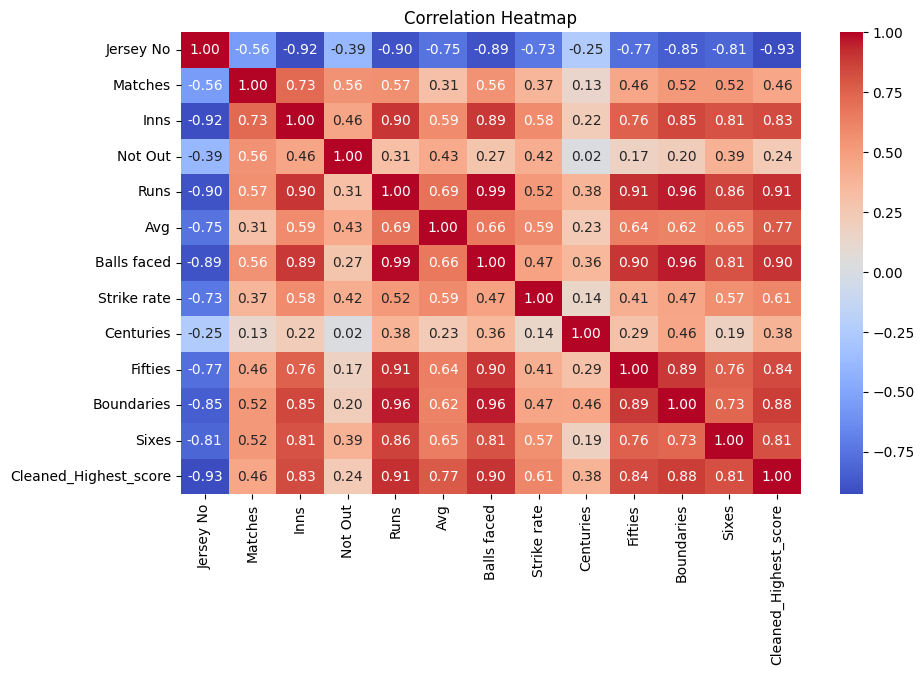

In [164]:
ipl_corr = ipl.drop(["Player","Highest Score","First Name","Last Name"],axis=1)
plt.figure(figsize=(10,6))
sns.heatmap(ipl_corr.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

__Q8: Players with Avg > 50 and Strike rate > 120__

In [166]:
high_perf_players = ipl[(ipl['Avg'] > 50) & (ipl['Strike rate'] > 120)][['Player', 'Avg', 'Strike rate']]
display(high_perf_players)

,Player,Avg,Strike rate
0,KL Rahul,55.83,129.34
4,Ishan Kishan,57.33,145.76
31,Kieron Pollard,53.60,191.42
36,Wriddhiman Saha,71.33,139.86
37,Ruturaj Gaikwad,51.00,120.71
57,Deepak Hooda,101.00,142.25
60,Tom Curran,83.00,133.87


__Q9: Players with Avg > 40 and Balls Faced > 100__

In [236]:
consistent_players = ipl[(ipl['Avg'] > 40) & (ipl['Balls faced'] > 100)][['Player', 'Avg', 'Balls faced']]
display(consistent_players)

,Player,Avg,Balls faced
0,KL Rahul,55.83,518
1,Shikhar Dhawan,44.14,427
4,Ishan Kishan,57.33,354
8,Virat Kohli,42.36,384
9,ABD Villiers,45.40,286
10,Faf Duplessis,40.81,319
14,Eoin Morgan,41.80,302
24,Kane Williamson,45.28,237
27,Chris Gayle,41.14,210
28,Ben Stokes,40.71,200


__Q10: Players who scored at least one century__

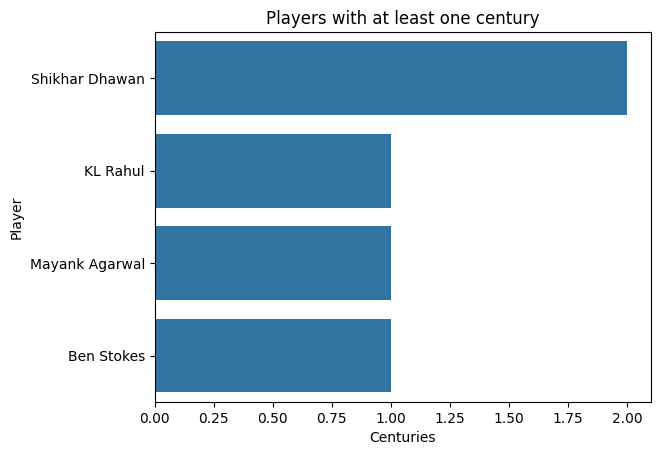

In [170]:
ipl_century = ipl[ipl['Centuries'] > 0]
sns.barplot(y='Player', x='Centuries', data=ipl_century.sort_values('Centuries', ascending=False))
plt.title("Players with at least one century")
plt.show()

__Q11: Players who scored at least 4 half-centuries__

In [238]:
ipl_half_century = ipl[ipl['Fifties'] >= 4][['Player', 'Fifties']]
display(ipl_half_century)

,Player,Fifties
0,KL Rahul,5
1,Shikhar Dhawan,4
2,David Warner,4
4,Ishan Kishan,4
5,Quinton Kock,4
6,Suryakumar Yadav,4
7,Devdutt Padikkal,5
9,ABD Villiers,5
10,Faf Duplessis,4


__Q12: Players who hit more than 45 boundaries and more than 10 sixes__

In [240]:
boundary_six_hitters = ipl[(ipl['Boundaries'] > 45) & (ipl['Sixes'] > 10)][['Player', 'Boundaries', 'Sixes']]
display(boundary_six_hitters)

,Player,Boundaries,Sixes
0,KL Rahul,58,23
1,Shikhar Dhawan,67,12
2,David Warner,52,14
5,Quinton Kock,46,22
6,Suryakumar Yadav,61,11


__Q13: Histogram of matches played__

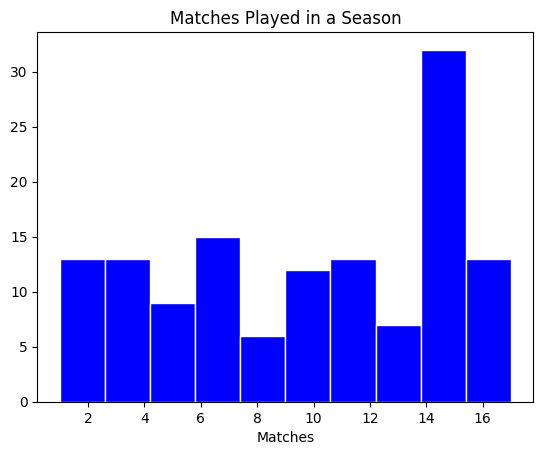

In [182]:
plt.hist(ipl['Matches'], bins=10, color='blue',edgecolor="white",label=True)
plt.xlabel("Matches")
plt.title("Matches Played in a Season")
plt.show()

__Q14: Histogram of balls faced by players__

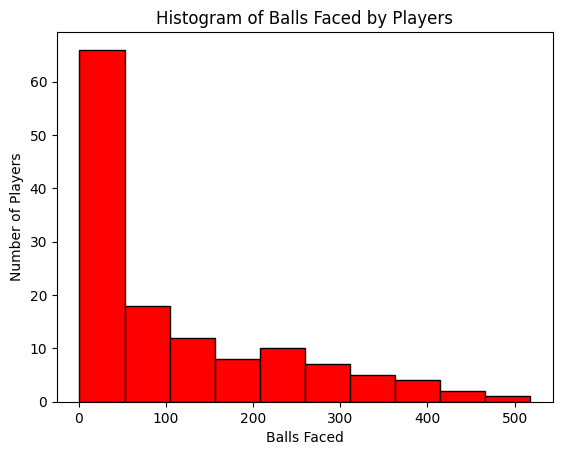

In [262]:
plt.hist(ipl['Balls faced'], bins=10,color="red" ,edgecolor='black')
plt.xlabel("Balls Faced")
plt.title("Histogram of Balls Faced by Players")
plt.show()

__Q15: Top 10 players with most runs in a season__

In [186]:
top_scorers = ipl.nlargest(10, 'Runs')[['Player', 'Runs']]
display(top_scorers)

,Player,Runs
0,KL Rahul,670
1,Shikhar Dhawan,618
2,David Warner,548
3,Shreyas Iyer,519
4,Ishan Kishan,516
5,Quinton Kock,503
6,Suryakumar Yadav,480
7,Devdutt Padikkal,473
8,Virat Kohli,466
9,ABD Villiers,454


__Q16: Players who played the match but didn't get to bat__

In [188]:
players_no_batting = ipl[ipl['Inns'] == 0]['Player']
display(players_no_batting)

Series([], Name: Player, dtype: object)

__Q17: Percentage of runs scored in 4s and 6s__

In [190]:
ipl['Boundary_Percentage'] = round(((ipl['Boundaries'] * 4 + ipl['Sixes'] * 6) / ipl['Runs']) * 100,2)
top_boundary_players = ipl.nlargest(10, 'Boundary_Percentage')[['Player', 'Boundary_Percentage']]
display(top_boundary_players)

,Player,Boundary_Percentage
109,Andrew Tye,100.00
48,Andre Russell,76.92
74,Chris Morris,76.47
29,Hardik Pandya,73.31
47,Sunil Narine,72.73
97,Mohammad Nabi,72.73
31,Kieron Pollard,71.64
50,Jofra Archer,70.80
26,Shane Watson,70.23
18,Nitish Rana,69.32


__Q18: Players with top 5 Not Out percentages__

In [194]:
ipl['Not_Out_Percentage'] = (ipl['Not Out'] / ipl['Inns']) * 100
top_not_out_players = ipl.nlargest(10, 'Not_Out_Percentage')[['Player', 'Not_Out_Percentage']]
display(top_not_out_players)

,Player,Not_Out_Percentage
62,Gurkeerat Singh,100.0
68,Lockie Ferguson,100.0
93,Imran Tahir,100.0
97,Mohammad Nabi,100.0
105,Pravin Dubey,100.0
110,Jasprit Bumrah,100.0
113,Dhawal Kulkarni,100.0
114,T Natarajan,100.0
115,Prasidh Krishna,100.0
116,Rahul Chahar,100.0


__Q19: Visualization of top 10 players with highest number of sixes__

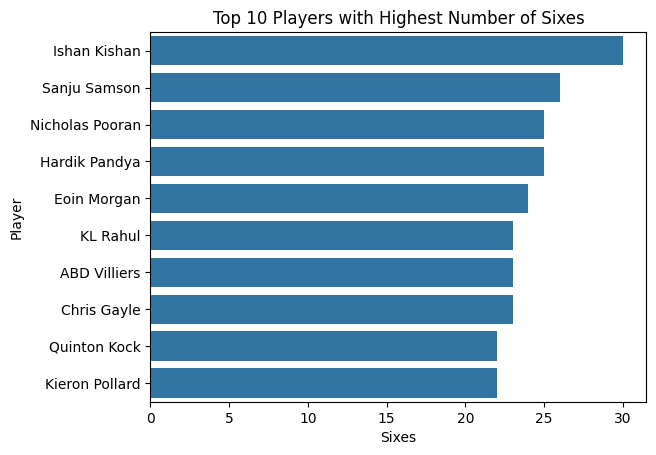

In [122]:
top_six_hitters = ipl.nlargest(10, 'Sixes')
sns.barplot(y='Player', x='Sixes', data=top_six_hitters.sort_values('Sixes', ascending=False))
plt.title("Top 10 Players with Highest Number of Sixes")
plt.show()

__Q20: Scatter plot of runs scored vs balls faced__

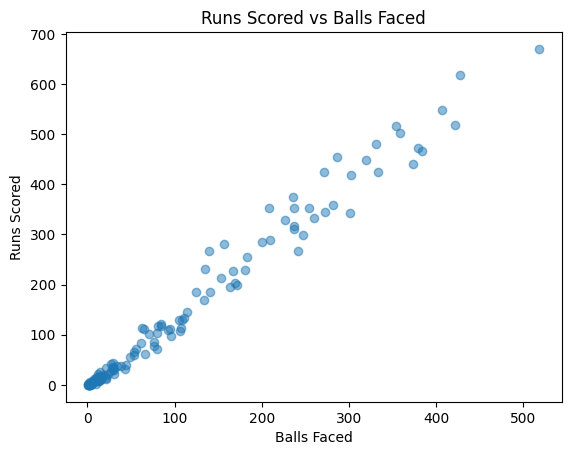

In [124]:
plt.scatter(ipl['Balls faced'], ipl['Runs'], alpha=0.5)
plt.xlabel("Balls Faced")
plt.ylabel("Runs Scored")
plt.title("Runs Scored vs Balls Faced")
plt.show()

__Correlation between Runs and Balls Faced__

In [196]:
correlation = ipl[['Balls faced', 'Runs']].corr()#.iloc[0,1]
display(round(correlation,4))

,Balls faced,Runs
Balls faced,1.0000,0.9899
Runs,0.9899,1.0000
